In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model("google_genai:gemini-3-flash-preview")
res = model.invoke("hii who am i")
print(res.text)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Hello! Since I am an AI, I don’t actually know your name or who you are in real life. I don't have access to your personal information or your identity unless you choose to share it with me.

To me, you are a person I'm having a conversation with right now! 

**If you’d like, you can tell me:**
1. What your name is?
2. What you’re interested in?
3. How I can help you today?

Who would you like to be today?


In [22]:
from pydantic import BaseModel , Field

class GraphSchema(BaseModel):
    title:str = Field(..., description="The title of the post")
    post:str = Field(..., description="The post content for instagram post.")
    curated_post:str = Field(..., description="The curated post content")


In [23]:
def create_post(state:GraphSchema)->GraphSchema:
    title = state.title
    content = model.invoke(f"Create a post for title {title}").text
    state.post = content
    return state

In [24]:
def curated_post(state:GraphSchema)->GraphSchema:
    post = state.post
    content = model.invoke(f"Create a post for title {post}").text
    state.curated_post = content
    return state

In [25]:
from langgraph.graph import StateGraph , START,END

graph = StateGraph(GraphSchema)

graph.add_node("create_post",create_post)
graph.add_node("curated_post",curated_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curated_post")
graph.add_edge("curated_post",END)

graph = graph.compile()


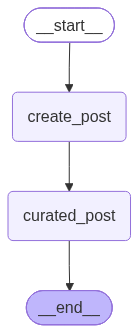

In [26]:
graph

In [27]:
graph.invoke({
    "title":"elephant",
    "post":"",
    "curated_post":""
})

{'title': 'elephant',
 'post': 'To give you the best post, I’ve broken this down into four different styles depending on where you want to post it (Instagram, LinkedIn, or a general fun fact style).\n\n### Option 1: Inspirational & Soulful (Best for Instagram/Facebook)\n**Caption:**\nThere is something deeply humbling about being in the presence of a giant. 🐘✨\n\nDid you know that elephants are one of the few species on Earth that show empathy, mourn their dead, and recognize themselves in mirrors? They carry the wisdom of the wild in their stride and a lifetime of memories in their hearts. \n\nLet’s be more like the elephant: move with purpose, protect our herd, and never forget those who helped us along the way.\n\n**Hashtags:** #GentleGiants #ElephantLove #NaturePhotography #WildlifeWisdom #NatureLovers #ProtectTheHerd\n\n---\n\n### Option 2: Fun & Educational (Best for X/Twitter or Threads)\n**Caption:**\nElephant Fact of the Day: An elephant’s trunk has over 40,000 muscles! To put